# Late Fusion by Reaction Time Groups - With EEG

This notebook splits trials into reaction time groups (Fast/Medium/Slow) and runs late fusion separately for each group, **including EEG as a fourth modality**.

**Note**: EEG data is only available for **10 subjects**, so this analysis is limited to those subjects.

**Parameterized**: Set `TIMEFRAME` to run PRE or POST analysis.

In [1]:
# ============================================================================
# CONFIGURATION: Set timeframe for analysis
# ============================================================================
TIMEFRAME = 'PRE'  # Options: 'PRE', 'POST'
# ============================================================================

import sys
sys.path.append('../..')  # Add project root to path

import pickle
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score, f1_score
from sklearn.impute import SimpleImputer
from scipy import stats, signal
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Import from src package
from src.utils.io import load_features, save_results
from src.utils.validation import validate_features
from src.models.fusion import weighted_late_fusion
from src.visualization.plots import set_style

np.random.seed(42)
set_style('whitegrid')

print(f"\n{'='*70}")
print(f"REACTION TIME GROUP ANALYSIS WITH EEG: {TIMEFRAME}-DECISION PERIOD")
print(f"{'='*70}\n")


REACTION TIME GROUP ANALYSIS WITH EEG: PRE-DECISION PERIOD



## 1. Load Pre-Extracted Features

In [2]:
# Load pre-extracted features using src utilities
features_path = f'../../data/results/features_{TIMEFRAME}/extracted_features_{TIMEFRAME}.pkl'
feature_data = load_features(features_path, timeframe=TIMEFRAME)

merged_df = feature_data['merged_df']
physio_cols = feature_data['physio_cols']
behavior_cols = feature_data['behavior_cols']
gaze_cols = feature_data['gaze_cols']

# Validate loaded features
validate_features(merged_df, timeframe=TIMEFRAME)

# Check reaction time column
rt_col = 'reaction_time' if 'reaction_time' in merged_df.columns else 'decision_time'
print(f"\nUsing column: {rt_col}")
print(f"Reaction time stats (all subjects):")
print(merged_df[rt_col].describe())

✓ Validation passed (PRE): 12511 trials, 97 subjects
  Trials per subject: min=9, max=246, mean=129.0
  Outcome balance: 4273 keep / 8238 invest

Using column: reaction_time
Reaction time stats (all subjects):
count    12511.000000
mean         1.591410
std          0.732791
min          0.144252
25%          1.032831
50%          1.410741
75%          1.976653
max          4.575594
Name: reaction_time, dtype: float64


## 2. Load and Extract EEG Features

In [3]:
# EEG feature extraction parameters
freq_bands = {
    'Delta': (0.5, 4),
    'Theta': (4, 8),
    'Alpha': (8, 13),
    'Beta': (13, 30),
    'Gamma': (30, 50)
}

channel_names = [
    'Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8',
    'T3', 'C3', 'Cz', 'C4', 'T4',
    'T5', 'P3', 'Pz', 'P4', 'T6',
    'O1', 'Oz', 'O2'
]

channel_regions = {
    'Frontal': ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8'],
    'Central': ['T3', 'C3', 'Cz', 'C4', 'T4'],
    'Parietal': ['T5', 'P3', 'Pz', 'P4', 'T6'],
    'Occipital': ['O1', 'Oz', 'O2']
}

def compute_band_power(eeg_data, fs=256, bands=None):
    """Compute band power for each channel and frequency band."""
    if bands is None:
        bands = freq_bands
    
    freqs, psd = signal.welch(eeg_data, fs=fs, nperseg=min(256, eeg_data.shape[1]))
    
    band_powers = {}
    for band_name, (f_low, f_high) in bands.items():
        freq_mask = (freqs >= f_low) & (freqs <= f_high)
        band_power = np.trapz(psd[:, freq_mask], freqs[freq_mask], axis=1)
        band_powers[band_name] = band_power
    
    return band_powers

def extract_eeg_features(eeg_df, fs=256):
    """Extract band power features for all trials."""
    features_list = []
    
    for idx, row in eeg_df.iterrows():
        review_eeg = np.array(row['review_eeg'])
        bp_review = compute_band_power(review_eeg, fs)
        
        trial_features = {
            'subject_id': row['subject_date_id'],
            'trial_id': f"{row['trial_id']}_{row['subject_date_id']}"
        }
        
        for band_name in freq_bands.keys():
            band_power = bp_review[band_name]
            for region, channels in channel_regions.items():
                ch_indices = [channel_names.index(ch) for ch in channels]
                avg_power = np.mean(band_power[ch_indices])
                trial_features[f'eeg_{band_name}_{region}'] = avg_power
        
        features_list.append(trial_features)
    
    return pd.DataFrame(features_list)

# Load preprocessed EEG data (10 subjects)
eeg_file = f'../../data/eeg/preprocessed_eeg_10_subjects_{TIMEFRAME.lower()}.pkl'
print(f"Loading EEG data from: {eeg_file}")
with open(eeg_file, 'rb') as f:
    eeg_raw_df = pickle.load(f)

print(f"Loaded {len(eeg_raw_df)} EEG trials from {eeg_raw_df['subject_date_id'].nunique()} subjects")

# Extract EEG features
print("\nExtracting EEG features...")
eeg_features_df = extract_eeg_features(eeg_raw_df, fs=256)
eeg_cols = [c for c in eeg_features_df.columns if c.startswith('eeg_')]

print(f"Extracted {len(eeg_cols)} EEG features")
print(f"EEG subjects: {eeg_features_df['subject_id'].unique()}")

Loading EEG data from: ../../data/eeg/preprocessed_eeg_10_subjects_pre.pkl
Loaded 1287 EEG trials from 10 subjects

Extracting EEG features...
Extracted 20 EEG features
EEG subjects: ['0831_1300_9M4VCHG' '0811_1000_U9TEJGM' '0831_1300_539136F'
 '0825_1300_539136F' '0825_1300_9M4VCHG' '0923_1000_U9TEJGM'
 '0824_1000_U9TEJGM' '0920_1600_U9TEJGM' '0818_1600_539136F'
 '0818_1600_9M4VCHG']


## 3. Merge Features and Filter to EEG Subjects

In [4]:
# Get EEG subjects
eeg_subjects = eeg_features_df['subject_id'].unique()
print(f"EEG subjects ({len(eeg_subjects)}): {eeg_subjects}")

# Filter merged_df to only EEG subjects
merged_df_eeg = merged_df[merged_df['subject_id'].isin(eeg_subjects)].copy()
print(f"\nFiltered to EEG subjects: {len(merged_df_eeg)} trials")

# Merge with EEG features on trial_id
merged_df_eeg = merged_df_eeg.merge(
    eeg_features_df[['trial_id'] + eeg_cols],
    on='trial_id',
    how='inner'
)

print(f"After merging with EEG: {len(merged_df_eeg)} trials")
print(f"Subjects: {merged_df_eeg['subject_id'].nunique()}")

# Check outcome balance
outcome_counts = merged_df_eeg['outcome'].value_counts()
print(f"\nOutcome balance: {outcome_counts.get(0, 0)} keep / {outcome_counts.get(1, 0)} invest")

EEG subjects (10): ['0831_1300_9M4VCHG' '0811_1000_U9TEJGM' '0831_1300_539136F'
 '0825_1300_539136F' '0825_1300_9M4VCHG' '0923_1000_U9TEJGM'
 '0824_1000_U9TEJGM' '0920_1600_U9TEJGM' '0818_1600_539136F'
 '0818_1600_9M4VCHG']

Filtered to EEG subjects: 1210 trials
After merging with EEG: 1173 trials
Subjects: 10

Outcome balance: 389 keep / 784 invest


## 4. Create Reaction Time Groups

In [5]:
# Create reaction time groups using tertiles
rt_col = 'reaction_time' if 'reaction_time' in merged_df_eeg.columns else 'decision_time'

# Calculate tertile boundaries
rt_33 = merged_df_eeg[rt_col].quantile(0.33)
rt_66 = merged_df_eeg[rt_col].quantile(0.66)

print(f"Reaction time tertile boundaries (EEG subjects):")
print(f"  Fast: < {rt_33:.3f}s")
print(f"  Medium: {rt_33:.3f}s - {rt_66:.3f}s")
print(f"  Slow: > {rt_66:.3f}s")

# Assign groups
def assign_rt_group(rt):
    if rt < rt_33:
        return 'Fast'
    elif rt < rt_66:
        return 'Medium'
    else:
        return 'Slow'

merged_df_eeg['rt_group'] = merged_df_eeg[rt_col].apply(assign_rt_group)

print("\nReaction time group distribution (EEG subjects only):")
print(merged_df_eeg['rt_group'].value_counts())

print(f"\nFeature counts:")
print(f"  Physiology ({TIMEFRAME}): {len(physio_cols)} features")
print(f"  Behavior: {len(behavior_cols)} features")
print(f"  Gaze: {len(gaze_cols)} features")
print(f"  EEG: {len(eeg_cols)} features")

Reaction time tertile boundaries (EEG subjects):
  Fast: < 1.144s
  Medium: 1.144s - 1.717s
  Slow: > 1.717s

Reaction time group distribution (EEG subjects only):
rt_group
Slow      399
Medium    387
Fast      387
Name: count, dtype: int64

Feature counts:
  Physiology (PRE): 13 features
  Behavior: 7 features
  Gaze: 20 features
  EEG: 20 features


## 5. Run Late Fusion for Each Reaction Time Group

In [6]:
# Run late fusion for each reaction time group
group_results = {}

for group in ['Fast', 'Medium', 'Slow']:
    print(f"\n{'='*80}")
    print(f"Analyzing {group} Reaction Time Group (with EEG)")
    print(f"{'='*80}")
    
    # Filter data for this group
    group_df = merged_df_eeg[merged_df_eeg['rt_group'] == group].copy()
    
    # Check if we have enough subjects
    n_subjects = group_df['subject_id'].nunique()
    if n_subjects < 3:
        print(f"  Skipping - only {n_subjects} subjects in this group")
        continue
    
    # Prepare feature matrices
    imputer = SimpleImputer(strategy='mean')
    X_physio = imputer.fit_transform(group_df[physio_cols])
    X_behavior = imputer.fit_transform(group_df[behavior_cols])
    X_gaze = imputer.fit_transform(group_df[gaze_cols]) if len(gaze_cols) > 0 else np.zeros((len(group_df), 1))
    X_eeg = imputer.fit_transform(group_df[eeg_cols])
    
    y = group_df['outcome'].values
    subjects = group_df['subject_id'].values
    
    # Setup modalities (include EEG)
    if len(gaze_cols) > 0:
        X_modalities = [X_physio, X_behavior, X_gaze, X_eeg]
        modality_names = ['Physiology', 'Behavior', 'Gaze', 'EEG']
    else:
        X_modalities = [X_physio, X_behavior, X_eeg]
        modality_names = ['Physiology', 'Behavior', 'EEG']
    
    # Get RT range for this group
    rt_min = group_df[rt_col].min()
    rt_max = group_df[rt_col].max()
    
    print(f"\nRunning weighted late fusion for {group} group...")
    print(f"  RT range: {rt_min:.3f}s - {rt_max:.3f}s")
    print(f"  N trials: {len(y)}")
    print(f"  N subjects: {n_subjects}")
    print(f"  Outcome: {(y==0).sum()} keep / {(y==1).sum()} invest")
    
    # Run fusion
    results = weighted_late_fusion(X_modalities, y, subjects, modality_names)
    results['modality_names'] = modality_names
    results['rt_range'] = (rt_min, rt_max)
    group_results[group] = results
    
    print(f"\nResults for {group} group:")
    print(f"  Accuracy: {results['accuracy_mean']:.3f} +/- {results['accuracy_sem']:.3f} (SEM)")
    print(f"  F1-Score: {results['f1_mean']:.3f} +/- {results['f1_sem']:.3f} (SEM)")
    print(f"  Weights:")
    for name, w in zip(modality_names, results['weights']):
        print(f"    {name}: {w*100:.1f}%")


Analyzing Fast Reaction Time Group (with EEG)

Running weighted late fusion for Fast group...
  RT range: 0.566s - 1.144s
  N trials: 387
  N subjects: 10
  Outcome: 91 keep / 296 invest

Results for Fast group:
  Accuracy: 0.722 +/- 0.059 (SEM)
  F1-Score: 0.692 +/- 0.065 (SEM)
  Weights:
    Physiology: 1.1%
    Behavior: 96.8%
    Gaze: 1.6%
    EEG: 0.6%

Analyzing Medium Reaction Time Group (with EEG)

Running weighted late fusion for Medium group...
  RT range: 1.144s - 1.711s
  N trials: 387
  N subjects: 10
  Outcome: 135 keep / 252 invest

Results for Medium group:
  Accuracy: 0.646 +/- 0.046 (SEM)
  F1-Score: 0.599 +/- 0.055 (SEM)
  Weights:
    Physiology: 4.6%
    Behavior: 90.7%
    Gaze: 3.0%
    EEG: 1.6%

Analyzing Slow Reaction Time Group (with EEG)

Running weighted late fusion for Slow group...
  RT range: 1.722s - 4.264s
  N trials: 399
  N subjects: 10
  Outcome: 163 keep / 236 invest

Results for Slow group:
  Accuracy: 0.605 +/- 0.055 (SEM)
  F1-Score: 0.519 +/-

## 6. Compare Results Across Groups

In [7]:
# Build comparison dataframe
comparison_rows = []
for group, results in group_results.items():
    modality_names = results.get('modality_names', ['Physiology', 'Behavior', 'Gaze', 'EEG'])
    rt_range = results.get('rt_range', (0, 0))
    row = {
        'Group': group,
        'RT_Min': rt_range[0],
        'RT_Max': rt_range[1],
        'N_Trials': results['n_trials'],
        'N_Subjects': results['n_subjects'],
        'Accuracy': results['accuracy_mean'],
        'Accuracy_SEM': results['accuracy_sem'],
        'Accuracy_SD': results['accuracy_std'],
        'F1-Score': results['f1_mean'],
        'F1_SEM': results['f1_sem'],
    }
    # Add weights for each modality
    for i, name in enumerate(modality_names):
        row[f'{name}_Weight'] = results['weights'][i] if i < len(results['weights']) else 0
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows)

print("\n" + "="*80)
print(f"COMPARISON ACROSS REACTION TIME GROUPS - WITH EEG (N={merged_df_eeg['subject_id'].nunique()} subjects)")
print("="*80)
print(comparison_df[['Group', 'RT_Min', 'RT_Max', 'N_Trials', 'N_Subjects', 'Accuracy', 'Accuracy_SEM', 'F1-Score']].to_string(index=False))

print("\n" + "="*80)
print("NOTE: This analysis uses only 10 subjects (those with EEG data)")
print("RT groups are based on tertiles of reaction time distribution")
print("="*80)


COMPARISON ACROSS REACTION TIME GROUPS - WITH EEG (N=10 subjects)
 Group   RT_Min   RT_Max  N_Trials  N_Subjects  Accuracy  Accuracy_SEM  F1-Score
  Fast 0.566201 1.143571       387          10  0.721751      0.059353  0.691847
Medium 1.143581 1.711422       387          10  0.645837      0.045824  0.598975
  Slow 1.721645 4.263513       399          10  0.605214      0.054953  0.518511

NOTE: This analysis uses only 10 subjects (those with EEG data)
RT groups are based on tertiles of reaction time distribution


## 7. Visualizations

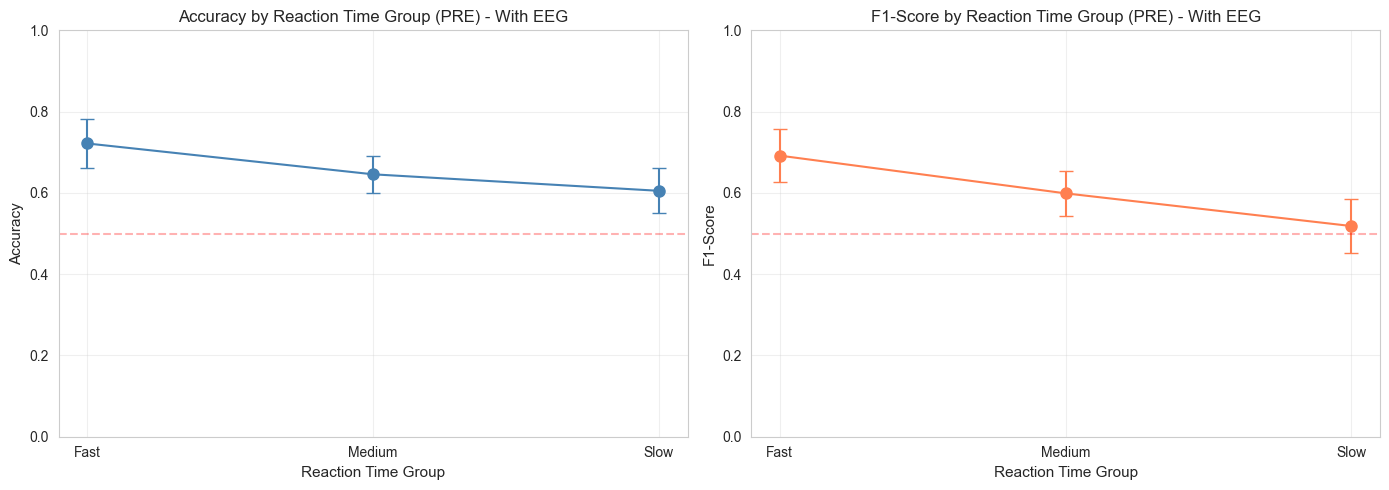

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy with SEM error bars
ax = axes[0]
ax.errorbar(comparison_df['Group'], comparison_df['Accuracy'], 
            yerr=comparison_df['Accuracy_SEM'], fmt='o-', capsize=5, color='steelblue', markersize=8)
ax.set_xlabel('Reaction Time Group')
ax.set_ylabel('Accuracy')
ax.set_title(f'Accuracy by Reaction Time Group ({TIMEFRAME}) - With EEG')
ax.set_ylim([0, 1])
ax.axhline(0.5, color='red', linestyle='--', alpha=0.3, label='Chance')
ax.grid(alpha=0.3)

# F1-Score with SEM error bars
ax = axes[1]
ax.errorbar(comparison_df['Group'], comparison_df['F1-Score'], 
            yerr=comparison_df['F1_SEM'], fmt='o-', capsize=5, color='coral', markersize=8)
ax.set_xlabel('Reaction Time Group')
ax.set_ylabel('F1-Score')
ax.set_title(f'F1-Score by Reaction Time Group ({TIMEFRAME}) - With EEG')
ax.set_ylim([0, 1])
ax.axhline(0.5, color='red', linestyle='--', alpha=0.3)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

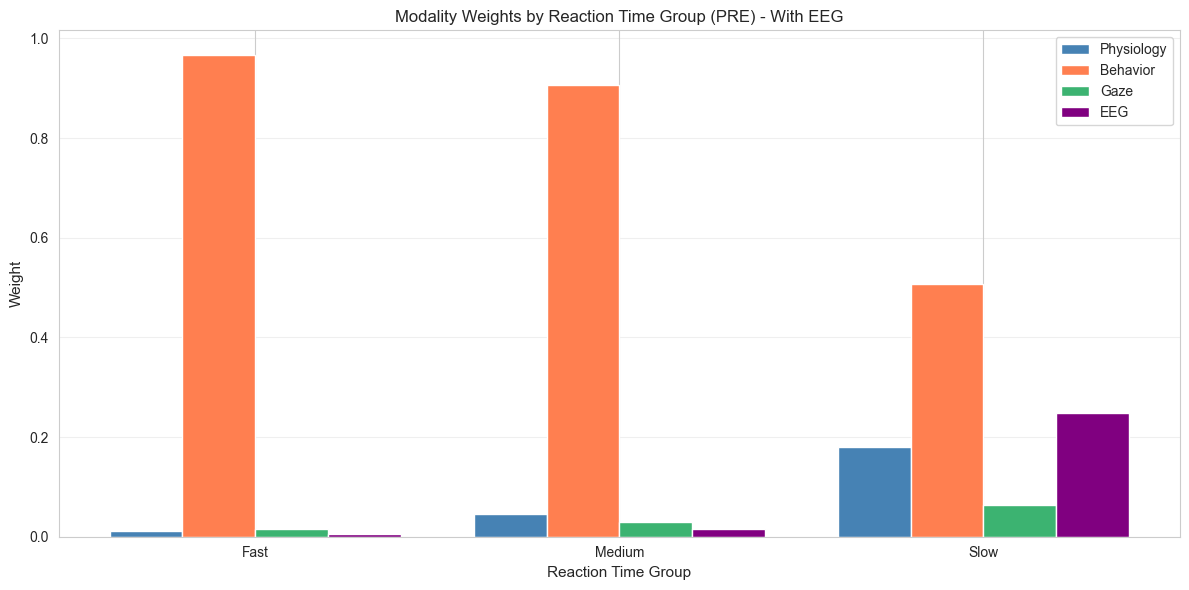

In [9]:
# Modality weights by group (including EEG)
fig, ax = plt.subplots(figsize=(12, 6))

# Get modality columns
weight_cols = [c for c in comparison_df.columns if c.endswith('_Weight')]
modality_names_plot = [c.replace('_Weight', '') for c in weight_cols]

x = np.arange(len(comparison_df))
width = 0.2
colors = ['steelblue', 'coral', 'mediumseagreen', 'purple']

for i, (col, name) in enumerate(zip(weight_cols, modality_names_plot)):
    offset = (i - len(weight_cols)/2 + 0.5) * width
    ax.bar(x + offset, comparison_df[col], width, label=name, color=colors[i % len(colors)])

ax.set_xlabel('Reaction Time Group')
ax.set_ylabel('Weight')
ax.set_title(f'Modality Weights by Reaction Time Group ({TIMEFRAME}) - With EEG')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Group'])
ax.legend()
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 8. Subject-Level Accuracy Distributions

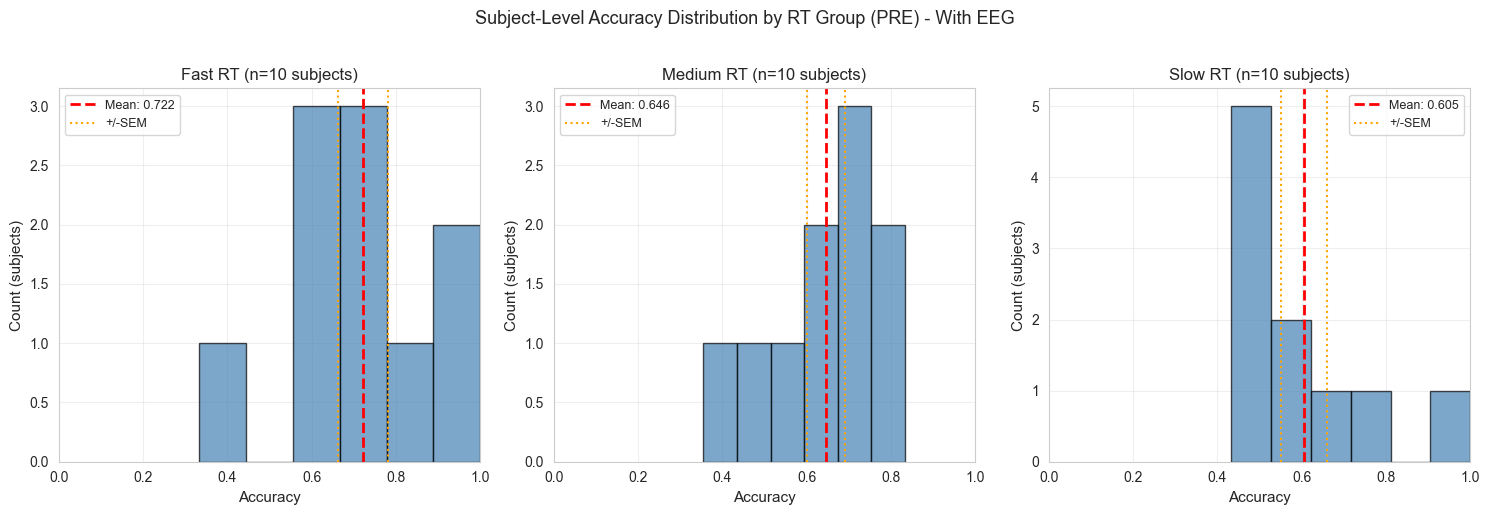

In [10]:
# Plot subject-level accuracy distributions for each RT group
n_groups = len(group_results)
fig, axes = plt.subplots(1, n_groups, figsize=(5*n_groups, 5))
if n_groups == 1:
    axes = [axes]

for idx, (group, results) in enumerate(group_results.items()):
    ax = axes[idx]
    subject_accs = results['accuracy_per_subject']
    
    # Histogram
    ax.hist(subject_accs, bins=6, color='steelblue', alpha=0.7, edgecolor='black')
    ax.axvline(results['accuracy_mean'], color='red', linestyle='--', linewidth=2,
               label=f"Mean: {results['accuracy_mean']:.3f}")
    ax.axvline(results['accuracy_mean'] - results['accuracy_sem'], color='orange',
               linestyle=':', linewidth=1.5, label=f"+/-SEM")
    ax.axvline(results['accuracy_mean'] + results['accuracy_sem'], color='orange',
               linestyle=':', linewidth=1.5)
    
    ax.set_xlabel('Accuracy')
    ax.set_ylabel('Count (subjects)')
    ax.set_title(f'{group} RT (n={results["n_subjects"]} subjects)')
    ax.set_xlim([0, 1])
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle(f'Subject-Level Accuracy Distribution by RT Group ({TIMEFRAME}) - With EEG', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 9. Save Results

In [11]:
import os
output_dir = f'../../data/results/fusion_models_eeg_{TIMEFRAME}'
os.makedirs(output_dir, exist_ok=True)

# Save comparison results across groups
save_results(comparison_df, f'{output_dir}/rt_group_eeg_{TIMEFRAME}_comparison.csv')

# Save detailed group results
for group_name, results in group_results.items():
    modality_names = results.get('modality_names', ['Physiology', 'Behavior', 'Gaze', 'EEG'])
    
    # Save modality weights
    weights_df = pd.DataFrame({
        'Modality': modality_names[:len(results['weights'])],
        'Weight': results['weights']
    })
    save_results(weights_df, f'{output_dir}/rt_group_eeg_{TIMEFRAME}_{group_name}_weights.csv')

    # Save subject-level accuracies
    if 'accuracy_per_subject' in results:
        subject_df = pd.DataFrame({
            'accuracy': results['accuracy_per_subject'],
            'f1_score': results.get('f1_per_subject', [])
        })
        save_results(subject_df, f'{output_dir}/rt_group_eeg_{TIMEFRAME}_{group_name}_subject_accuracies.csv')

print(f"\nAll results saved to: {output_dir}/")

✓ Saved results to: ../../data/results/fusion_models_eeg_PRE/rt_group_eeg_PRE_comparison.csv
✓ Saved results to: ../../data/results/fusion_models_eeg_PRE/rt_group_eeg_PRE_Fast_weights.csv
✓ Saved results to: ../../data/results/fusion_models_eeg_PRE/rt_group_eeg_PRE_Fast_subject_accuracies.csv
✓ Saved results to: ../../data/results/fusion_models_eeg_PRE/rt_group_eeg_PRE_Medium_weights.csv
✓ Saved results to: ../../data/results/fusion_models_eeg_PRE/rt_group_eeg_PRE_Medium_subject_accuracies.csv
✓ Saved results to: ../../data/results/fusion_models_eeg_PRE/rt_group_eeg_PRE_Slow_weights.csv
✓ Saved results to: ../../data/results/fusion_models_eeg_PRE/rt_group_eeg_PRE_Slow_subject_accuracies.csv

All results saved to: ../../data/results/fusion_models_eeg_PRE/
